# Donation-Intent Classifier Training — v8: Hierarchical + Augmentation Plus

Combines the two most promising, evidence-backed changes tried so far,
which had only been tested separately:

- **v6's hierarchical dialogue encoder** (OOM-fixed — see
  [architecture-v6.md](architecture-v6.md)): turn-level encoding +
  dialogue Transformer, replacing the flat 256-token truncated sequence.
- **v7's augmentation upgrade** (see
  [architecture-v7.md](architecture-v7.md)): connective paraphrase +
  back-translation, replacing pure word-level EDA for `conditional`/
  `deferred` rows.

## Why combine them, based on what actually happened

v6's first run OOM'd on DeBERTa-v3, but **RoBERTa-base completed its full
run before the crash**, and the result was striking:

| Metric | v3-v5 flat model (range, all runs) | v6 RoBERTa (hierarchical) |
|---|---|---|
| binary macro-F1 | 0.610 – 0.698 | **0.80** (val, best epoch) |
| modifier macro-F1\|yes | 0.277 – 0.336 | **0.67** (val, best epoch) |

That's not an incremental gain — it's a different regime entirely. Median
dialogue length here is ~344 words; a 256-token flat encoder was
truncating the typical dialogue, and per `guideline.md` that usually
means losing the part that actually decides the label. The hierarchical
encoder removes that truncation almost entirely (max 30 turns observed,
`max_utterances=32` gives full headroom).

Meanwhile, **v7's augmentation-quality upgrade — tested on the flat
model — did not clearly help**:

| Class | v5 F1 (roberta/deberta/todbert) | v7 F1 (roberta/deberta/todbert) |
|---|---|---|
| `conditional` (support=3) | 0.00 / 0.00 / 0.00 | 0.00 / 0.00 / 0.00 |
| `deferred` (support=19) | 0.09 / 0.13 / 0.00 | 0.05 / 0.06 / 0.00 |
| binary macro-F1 | 0.648 / 0.670 / 0.623 | 0.610 / 0.698 / 0.611 |

Back-translation and the connective paraphrase op both ran correctly
(verified: 0% marker corruption on both the EDA and back-translation
paths — see `ran-nb/ran-v7.ipynb` cell 14's output), so this isn't a bug
report. It's evidence that **more diverse minority-class phrasing wasn't
the flat model's bottleneck** — truncation plausibly was, and v7 never
touched that. The natural next experiment is applying v7's augmentation
diversity to the architecture that already showed truncation removal
matters a great deal, rather than concluding augmentation quality doesn't
matter at all.

## What this notebook is

`HierarchicalDialogueClassifier` (v6, with the OOM fixes: reduced
DeBERTa-v3 batch size, gradient checkpointing on all three encoders,
`PYTORCH_CUDA_ALLOC_CONF`) trained on data produced by v7's augmentation
pipeline (connective paraphrase EDA op + per-turn back-translation for
`conditional`/`deferred`, with the same defensive EDA fallback if
back-translation fails to load). Loss (class-balanced focal + supervised
contrastive), binary-macro-F1 checkpoint selection, threshold tuning, and
the 3-encoder benchmark are unchanged from both parents.

One thing to watch for that neither parent could tell us alone: back-translated
turns are quite a bit shorter/differently-structured after a round-trip
through French (see the samples in `ran-nb/ran-v7.ipynb` cell 14) — worth
checking whether that interacts differently with `max_utterances`/
`max_utt_len` truncation than the original EDA-perturbed text did, since
the hierarchical model (unlike v7's flat one) actually preserves
per-turn structure through to the classifier.

## Compute cost

Same profile as the fixed v6: expect **1-3+ hours for all three
encoders** on a free Kaggle T4, plus a few extra minutes up front for
back-translation model download + one-time augmentation pass (same cost
v7 already paid). Outputs are suffixed `_v8` / `checkpoints_v8/`.

## 0b. Install / upgrade dependencies

In [1]:
# =============================================================
# 0b. INSTALL / UPGRADE DEPENDENCIES (online mode)
# =============================================================
import subprocess, sys

subprocess.run([
    sys.executable, "-m", "pip", "install", "-q", "-U",
    "transformers>=4.44.0,<4.47.0", "sentencepiece", "sacremoses", "tqdm",
    "seaborn", "scikit-learn",
], check=True)
# --no-deps: keep the GPU-matched torch already on the Kaggle image
subprocess.run([
    sys.executable, "-m", "pip", "install", "-q", "-U",
    "--no-deps", "accelerate>=0.34.0",
], check=True)
print("All required Python packages installed successfully.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 72.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 62.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 867.8/867.8 kB 38.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.2/80.2 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 104.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 32.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 94.1 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.
sklearn-compat 0.1.5 requires scikit-learn<1.9,>=1.2, but you have scikit-learn 1.9.0 which is incompatible.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 10.5 MB/s eta 0:00:00
All required Python packages installed successfully.


## 1. Imports & global config

In [2]:
# =============================================================
# 1. IMPORTS & GLOBAL CONFIG
# =============================================================
import os
# Set BEFORE torch initializes its CUDA allocator -- mitigates the
# fragmentation-related OOM v6 hit on DeBERTa-v3 (see the intro cell for
# the failure and the fix rationale). Directly what the error message
# itself suggested.
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

import re, json, glob, gc, time, warnings, random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, precision_recall_fscore_support,
                              classification_report, confusion_matrix)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 120)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")
print(f"torch version: {torch.__version__} (built for CUDA {torch.version.cuda})")
if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# ---- CONFIG: the only block you should need to touch -----------------
CONFIG = {
    # Same fuzzy recursive search-root convention as v3, so this works
    # unmodified whether the labeled CSV is added as a Kaggle Dataset
    # input or dropped anywhere under these roots.
    "search_roots": ["/kaggle/input", "/kaggle/working", "/workspace", "/data", "."],

    "out_dir": "/kaggle/working" if os.path.isdir("/kaggle/working") else "./outputs",
    # v8 writes its own output filenames (suffixed "_v8") and its own
    # checkpoint subdirectory, so this can run in the same out_dir as
    # v3-v7 without clobbering their artifacts.
    "run_tag": "v8",

    "column_map": {
        "text": "dialogue_text",
        "binary_label": "binary_label",
        "modifier": "modifier",
    },

    "binary_classes": ["no", "yes"],
    "modifier_classes": ["none", "deferred", "conditional"],

    # Batch sizes are lower than v3/v4/v5's: the utterance encoder sees
    # batch_size * (turns/dialogue, ~20 typical, up to 32) flattened
    # sequences per forward pass instead of batch_size whole dialogues,
    # so effective memory pressure is much higher per training step even
    # though each individual sequence is short.
    #
    # FIX (post-OOM): the first v6 run OOM'd on DeBERTa-v3 -- it crashed
    # before completing epoch 1 with 14.13/14.56 GiB already allocated on
    # a T4, even at batch_size=4 (RoBERTa completed its full run fine at
    # batch_size=8, reaching val_binary_macroF1=0.80 / modifier_macroF1|
    # yes=0.67 before the crash on the next encoder -- see the intro cell).
    # DeBERTa-v2/v3's disentangled attention builds extra O(L^2)
    # content-to-position/position-to-content bias tensors per layer that
    # RoBERTa/BERT-style attention doesn't, so it needs a much larger cut
    # here than it did for the flat model in v3/v4/v5 (batch_size=8 there
    # was enough; the B*U flattening here multiplies that pressure).
    # batch_size=2 (down from the failing 4) plus gradient checkpointing
    # (enabled unconditionally below, for all three encoders) should give
    # a large safety margin. eval_batch_size is overridden down too --
    # even under torch.no_grad(), a flattened [B*U, L] forward pass at
    # DeBERTa's per-token memory cost adds up at eval_batch_size=16.
    # If this still OOMs, the next lever to pull is batch_size=1.
    "encoders": [
        {"name": "roberta-base",    "hf_id": "roberta-base",          "batch_size": 8},
        {"name": "deberta-v3-base", "hf_id": "microsoft/deberta-v3-base", "lr": 5e-6, "batch_size": 2, "eval_batch_size": 4, "warmup_ratio": 0.10},
        {"name": "todbert",         "hf_id": "TODBERT/TOD-BERT-JNT-V1", "batch_size": 8},
    ],

    # Per-utterance token budget and max turns/dialogue. The real corpus
    # never exceeds 30 turns/dialogue (p95=23, p99=25) and 98.7% of
    # individual turns are under 64 words, so these give full headroom
    # with truncation essentially never firing (see the v6 intro cell for
    # the measured distribution).
    "max_utterances": 32,
    "max_utt_len": 64,

    # Dialogue-level Transformer (encodes discourse structure across the
    # sequence of turn vectors). README's HiTrans sketch suggests 6
    # layers; defaulting lower here since this dataset is small (~1000
    # augmented training dialogues) and a deep transformer over only
    # ~20 turn-vectors per example risks overfitting/instability faster
    # than it helps -- bump this if you have the compute budget to check.
    "dialogue_num_layers": 4,
    "dialogue_num_heads": 8,
    "train_frac": 0.70,
    "val_frac": 0.15,
    "test_frac": 0.15,

    "batch_size": 8,
    "eval_batch_size": 16,
    "num_epochs": 25,
    "lr": 2e-5,
    "weight_decay": 0.01,
    "warmup_ratio": 0.06,
    "max_grad_norm": 1.0,

    "binary_loss_weight": 1.0,
    "modifier_loss_weight": 0.7,

    # Data augmentation -- v8 uses v7's upgraded pipeline (connective
    # paraphrase + back-translation for conditional/deferred), applied
    # to text that then gets turn-split by the hierarchical model's
    # collate function exactly like real rows -- see architecture-v7.md
    # for the full rationale and architecture-v8's intro cell for why
    # it's paired with the hierarchical model specifically this time.
    "use_augmentation": True,
    "aug_alpha": 0.15,
    "aug_num_conditional_bt": 3,
    "aug_num_conditional_eda": 3,
    "aug_num_deferred_bt": 1,
    "aug_num_deferred_eda": 1,
    "aug_num_no": 1,
    "use_backtranslation": True,
    "backtranslation_pivot_lang": "fr",
    "backtranslation_max_len": 96,
    "aug_persuadee_bias_weight": 0.75,

    # ---- v4: Class-Balanced Focal Loss (replaces v3's inverse-freq
    # weighted CE + label smoothing) --------------------------------
    # "Class-Balanced Loss Based on Effective Number of Samples"
    # (Cui et al., 2019, CVPR). beta close to 1 -> weight ~ inverse
    # frequency for well-populated classes but saturates gracefully for
    # near-zero-sample classes (e.g. conditional) instead of exploding.
    "cb_beta": 0.999,
    # Focal-loss focusing parameter: down-weights already-easy/confident
    # predictions so the loss keeps pushing on hard/minority examples
    # for the whole run, not just at initialisation.
    "focal_gamma": 2.0,

    # ---- v4: Supervised Contrastive auxiliary loss --------------------
    # In-batch, single-stage (no separate pretraining pass -> cheap).
    # Pulls same-class pooled representations together / pushes apart.
    # Modifier weight is higher because that is the head that collapses
    # hardest (85.6% "none").
    "use_contrastive": True,
    "contrastive_temperature": 0.1,
    "contrastive_weight_binary": 0.10,
    "contrastive_weight_modifier": 0.30,

    "early_stopping_patience": 5,
    "checkpoint_dir_name": "checkpoints_v8",
}

os.makedirs(CONFIG["out_dir"], exist_ok=True)
os.makedirs(os.path.join(CONFIG["out_dir"], CONFIG["checkpoint_dir_name"]), exist_ok=True)
print(json.dumps({k: v for k, v in CONFIG.items() if k != "encoders"}, indent=2))
print("Encoders:", [m["hf_id"] for m in CONFIG["encoders"]])

Using device: cuda
torch version: 2.10.0+cu128 (built for CUDA 12.8)
GPU: Tesla T4
{
  "search_roots": [
    "/kaggle/input",
    "/kaggle/working",
    "/workspace",
    "/data",
    "."
  ],
  "out_dir": "/kaggle/working",
  "run_tag": "v8",
  "column_map": {
    "text": "dialogue_text",
    "binary_label": "binary_label",
    "modifier": "modifier"
  },
  "binary_classes": [
    "no",
    "yes"
  ],
  "modifier_classes": [
    "none",
    "deferred",
    "conditional"
  ],
  "max_utterances": 32,
  "max_utt_len": 64,
  "dialogue_num_layers": 4,
  "dialogue_num_heads": 8,
  "train_frac": 0.7,
  "val_frac": 0.15,
  "test_frac": 0.15,
  "batch_size": 8,
  "eval_batch_size": 16,
  "num_epochs": 25,
  "lr": 2e-05,
  "weight_decay": 0.01,
  "warmup_ratio": 0.06,
  "max_grad_norm": 1.0,
  "binary_loss_weight": 1.0,
  "modifier_loss_weight": 0.7,
  "use_augmentation": true,
  "aug_alpha": 0.15,
  "aug_num_conditional_bt": 3,
  "aug_num_conditional_eda": 3,
  "aug_num_deferred_bt": 1,
  "aug

## 2. Load the labeled dataset

In [3]:
# =============================================================
# 2. DATA DISCOVERY & LOADING  (unchanged from v3)
# =============================================================

def find_files_ci(roots, must_contain_all, suffix):
    must_contain_all = [t.lower() for t in must_contain_all]
    suffix = suffix.lower()
    found = []
    for root in roots:
        if not os.path.isdir(root):
            continue
        for dirpath, _dirnames, filenames in os.walk(root):
            for fn in filenames:
                low = fn.lower()
                if low.endswith(suffix) and all(tok in low for tok in must_contain_all):
                    found.append(os.path.join(dirpath, fn))
    seen, unique = set(), []
    for f in found:
        if f not in seen:
            seen.add(f)
            unique.append(f)
    return unique

csv_paths = find_files_ci(CONFIG["search_roots"], must_contain_all=["label"], suffix=".csv")
if not csv_paths:
    csv_paths = find_files_ci(CONFIG["search_roots"], must_contain_all=["manual"], suffix=".csv")

print(f"Found {len(csv_paths)} candidate CSV(s):")
for p in csv_paths:
    print(" -", p)

assert len(csv_paths) > 0, (
    "No labeled CSV found under " + str(CONFIG["search_roots"]) +
    ". Make sure the labeled dataset has been added as a Kaggle input "
    "(Notebook -> Add Input), or update CONFIG['search_roots']."
)

_dfs = [pd.read_csv(p) for p in csv_paths]
raw_df = pd.concat(_dfs, ignore_index=True) if len(_dfs) > 1 else _dfs[0]

cm = CONFIG["column_map"]
missing_cols = [c for c in cm.values() if c not in raw_df.columns]
assert not missing_cols, (
    f"Expected column(s) {missing_cols} not found in loaded CSV(s). "
    f"Columns present: {list(raw_df.columns)}. "
    "Update CONFIG['column_map'] to match the new dataset's headers."
)

df = raw_df.rename(columns={v: k for k, v in cm.items()})[list(cm.keys())].copy()

orig_id_col = None
for cand in ["conversation_id", "dialogue_id", "id"]:
    if cand in raw_df.columns:
        orig_id_col = cand
        break
if orig_id_col is not None:
    df["_orig_id"] = raw_df[orig_id_col].values
    before = len(df)
    df = df.drop_duplicates(subset="_orig_id").drop(columns="_orig_id").reset_index(drop=True)
    if len(df) != before:
        print(f"Dropped {before - len(df)} duplicate row(s) by `{orig_id_col}`.")

df["text"] = df["text"].fillna("").astype(str)
df["binary_label"] = df["binary_label"].fillna("").astype(str).str.strip().str.lower()

df["modifier"] = df["modifier"].fillna("").astype(str).str.strip().str.lower()
df.loc[df["modifier"].isin(["", "nan", "none provided", "na"]), "modifier"] = "none"

bad_binary = ~df["binary_label"].isin(CONFIG["binary_classes"])
bad_modifier = ~df["modifier"].isin(CONFIG["modifier_classes"])
if bad_binary.any() or bad_modifier.any():
    print(f"WARNING: dropping {int((bad_binary | bad_modifier).sum())} row(s) with "
          f"out-of-vocabulary binary_label/modifier values.")
    print("  bad binary_label values:", sorted(df.loc[bad_binary, "binary_label"].unique()))
    print("  bad modifier values:", sorted(df.loc[bad_modifier, "modifier"].unique()))
    df = df.loc[~(bad_binary | bad_modifier)].reset_index(drop=True)

df["binary_id"] = df["binary_label"].map({c: i for i, c in enumerate(CONFIG["binary_classes"])})
df["modifier_id"] = df["modifier"].map({c: i for i, c in enumerate(CONFIG["modifier_classes"])})

print(f"\nLoaded {len(df)} labeled rows after cleaning.")
df.head()

Found 1 candidate CSV(s):
 - /kaggle/input/datasets/nawrizturjo/persuasion-1/Manual_Label.csv

Loaded 1017 labeled rows after cleaning.


,text,binary_label,modifier,binary_id,modifier_id
0,"[Persuader] Good morning\n [Persuadee] Good morning \n [Persuader] We are seeking donations for the ""Save the Childr...",yes,none,1,0
1,[Persuader] Could you please donate all of your$2 to Save the Children? Hunger kills millions of children worldwide ...,yes,none,1,0
2,[Persuader] Hello! How are you doing?\n [Persuadee] I am quite good. How about yourself? \n [Persuader] I am doing a...,no,none,0,0
3,"[Persuader] Good evening. How are you doing?\n [Persuadee] I'm doing pretty good, how about yourself?\n [Persuader] ...",yes,none,1,0
4,[Persuader] Hi! How are you today?\n [Persuadee] good :) how are you?\n [Persuader] I'm good. Thanks for asking. Hav...,yes,none,1,0


## 2b. Class distribution & majority-class baseline

binary_label distribution:
binary_label
yes    738
no     279
Name: count, dtype: int64 

modifier distribution:
modifier
none           871
deferred       125
conditional     21
Name: count, dtype: int64 

modifier distribution, restricted to binary_label == 'yes' rows (the population the modifier head is conditioned on):
modifier
none           657
deferred        68
conditional     13
Name: count, dtype: int64


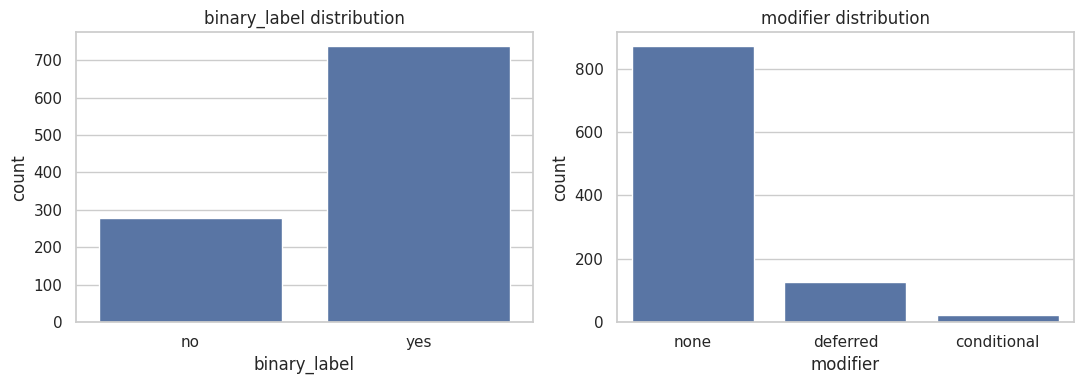


Majority-class baseline (whole dataset, for reference -- the real reported baseline further down uses the TEST split only):
  binary_label: {'majority_class': np.int64(1), 'accuracy': 0.7256637168141593, 'macro_f1': 0.4205128205128205}
  modifier    : {'majority_class': np.int64(0), 'accuracy': 0.856440511307768, 'macro_f1': 0.3075564971751413}


In [4]:
# =============================================================
# 2b. CLASS DISTRIBUTION & MAJORITY-CLASS BASELINE  (unchanged from v3)
# =============================================================
print("binary_label distribution:")
print(df["binary_label"].value_counts(), "\n")
print("modifier distribution:")
print(df["modifier"].value_counts(), "\n")
print("modifier distribution, restricted to binary_label == 'yes' rows "
      "(the population the modifier head is conditioned on):")
print(df.loc[df["binary_label"] == "yes", "modifier"].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(data=df, x="binary_label", order=CONFIG["binary_classes"], ax=axes[0])
axes[0].set_title("binary_label distribution")
sns.countplot(data=df, x="modifier", order=CONFIG["modifier_classes"], ax=axes[1])
axes[1].set_title("modifier distribution")
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["out_dir"], "label_distribution.png"), dpi=150)
plt.show()

def majority_baseline(y_true_ids, n_classes):
    majority_class = Counter(y_true_ids).most_common(1)[0][0]
    y_pred = [majority_class] * len(y_true_ids)
    acc = accuracy_score(y_true_ids, y_pred)
    f1_macro = f1_score(y_true_ids, y_pred, average="macro", labels=list(range(n_classes)), zero_division=0)
    return {"majority_class": majority_class, "accuracy": acc, "macro_f1": f1_macro}

baseline_binary = majority_baseline(df["binary_id"].values, len(CONFIG["binary_classes"]))
baseline_modifier = majority_baseline(df["modifier_id"].values, len(CONFIG["modifier_classes"]))

print("\nMajority-class baseline (whole dataset, for reference -- the real "
      "reported baseline further down uses the TEST split only):")
print("  binary_label:", baseline_binary)
print("  modifier    :", baseline_modifier)

## 3. Stratified 70/15/15 train/val/test split

In [5]:
# =============================================================
# 3. STRATIFIED 70/15/15 SPLIT (by binary_label x modifier combination) -- unchanged from v3
# =============================================================

df["_stratum"] = df["binary_label"] + "_" + df["modifier"]

strat_counts = df["_stratum"].value_counts()
rare = strat_counts[strat_counts < 2].index
df.loc[df["_stratum"].isin(rare), "_stratum"] = "_singleton_bucket"

train_df, temp_df = train_test_split(
    df, test_size=(CONFIG["val_frac"] + CONFIG["test_frac"]),
    stratify=df["_stratum"], random_state=SEED,
)
temp_counts = temp_df["_stratum"].value_counts()
rare2 = temp_counts[temp_counts < 2].index
temp_df = temp_df.copy()
temp_df.loc[temp_df["_stratum"].isin(rare2), "_stratum"] = "_singleton_bucket"

rel_test_size = CONFIG["test_frac"] / (CONFIG["val_frac"] + CONFIG["test_frac"])
val_df, test_df = train_test_split(
    temp_df, test_size=rel_test_size,
    stratify=temp_df["_stratum"], random_state=SEED,
)

for name, split in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(f"{name}: n={len(split)} ({len(split)/len(df):.1%})")

print("\nbinary_label composition per split:")
display(pd.concat({
    "train": train_df["binary_label"].value_counts(normalize=True),
    "val": val_df["binary_label"].value_counts(normalize=True),
    "test": test_df["binary_label"].value_counts(normalize=True),
}, axis=1))

print("\nmodifier composition per split:")
display(pd.concat({
    "train": train_df["modifier"].value_counts(normalize=True),
    "val": val_df["modifier"].value_counts(normalize=True),
    "test": test_df["modifier"].value_counts(normalize=True),
}, axis=1))

for split in (train_df, val_df, test_df):
    split.drop(columns=["_stratum"], inplace=True)
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

train: n=711 (69.9%)
val: n=153 (15.0%)
test: n=153 (15.0%)

binary_label composition per split:


,train,val,test
binary_label,,,
yes,0.724332,0.732026,0.72549
no,0.275668,0.267974,0.27451



modifier composition per split:


,train,val,test
modifier,,,
none,0.856540,0.856209,0.856209
deferred,0.122363,0.124183,0.124183
conditional,0.021097,0.019608,0.019608


## 3b. Data Augmentation — EDA + Connective Paraphrase + Back-Translation (v7)

In [6]:
# =============================================================
# 3b. AUGMENTATION (train split only, label-safety-guarded)  -- v7 adds:
#   1. connective-paraphrase EDA op (varies the PROTECTED_WORDS vocabulary
#      itself, via a hand-vetted meaning-preserving paraphrase table)
#   2. back-translation (README idea #4 technique A), per-turn, with a
#      defensive EDA fallback if model loading/translation fails
# Everything from v5 (marker-safe tokenizer, hashlib seeding, Persuadee-
# turn bias, the 4 original EDA ops) is unchanged.
# =============================================================
import re
import random as _random
import hashlib

PROTECTED_WORDS = {
    "if", "unless", "provided", "as", "long", "condition", "conditional",
    "after", "once", "later", "when", "then", "next", "eventually",
    "promise", "will", "would", "could", "might", "may", "maybe",
    "paycheck", "payday", "month", "week", "tomorrow", "soon",
    "not", "no", "never", "don't", "dont", "won't", "wont", "can't", "cant",
    "donate", "donation", "give", "money", "charity", "pledge",
}
SPEAKER_MARKERS = {"[persuader]", "[persuadee]"}

_SYNONYMS = {
    "good": ["nice", "great", "fine", "decent"],
    "really": ["truly", "genuinely", "honestly"],
    "think": ["believe", "feel", "figure"],
    "want": ["would like", "wish", "hope"],
    "help": ["assist", "support", "aid"],
    "people": ["folks", "individuals", "persons"],
    "important": ["significant", "vital", "essential"],
    "cause": ["mission", "campaign", "effort"],
    "understand": ["see", "get", "realize"],
    "sure": ["certain", "confident", "positive"],
    "sorry": ["apologies", "regret", "my bad"],
    "okay": ["alright", "fine", "sure"],
    "thanks": ["thank you", "appreciate it", "cheers"],
    "great": ["awesome", "wonderful", "fantastic"],
    "kids": ["children", "youth", "young ones"],
    "families": ["households", "homes"],
    "problem": ["issue", "trouble", "difficulty"],
    "talk": ["chat", "speak", "discuss"],
    "guess": ["suppose", "reckon", "figure"],
    "job": ["work", "career", "position"],
    "busy": ["swamped", "occupied", "tied up"],
}

# v7 NEW: hand-vetted, meaning-preserving paraphrases for exactly the
# connective/hedging vocabulary PROTECTED_WORDS locks down. Each mapping
# was chosen to preserve the conditional/deferred semantics that make the
# row's label valid (e.g. "if" -> "as long as" keeps the commitment
# conditional either way) -- this is a SEPARATE, controlled channel from
# the general synonym table above, never applied by the other four ops.
_CONNECTIVE_SYNONYMS = {
    "if": ["provided that", "as long as", "assuming", "so long as"],
    "unless": ["except if", "other than if"],
    "provided": ["given", "assuming"],
    "condition": ["stipulation", "requirement"],
    "after": ["once", "following"],
    "once": ["after", "as soon as"],
    "later": ["down the road", "afterward", "at a later time"],
    "eventually": ["in due time", "down the line"],
    "promise": ["commit to", "pledge to", "vow to"],
    "maybe": ["perhaps", "possibly"],
    "might": ["could", "may"],
    "soon": ["shortly", "before long"],
    "tomorrow": ["the next day"],
    "next": ["the following", "upcoming"],
}

def _get_synonym(word):
    lw = word.lower()
    if lw in _SYNONYMS:
        return _random.choice(_SYNONYMS[lw])
    return None

_TOKEN_PATTERN = re.compile(r'\[Persuader\]|\[Persuadee\]|\S+')

def _tokenize_protecting_markers(text):
    return _TOKEN_PATTERN.findall(text)

def _is_locked(tok):
    low = tok.strip(".,!?;:\"'").lower()
    return low in PROTECTED_WORDS or low in SPEAKER_MARKERS or tok.lower() in SPEAKER_MARKERS

def _tag_token_roles(words):
    roles = []
    current = "other"
    for w in words:
        low = w.lower()
        if low == "[persuader]":
            current = "persuader"
        elif low == "[persuadee]":
            current = "persuadee"
        roles.append(current)
    return roles

def _ranked_candidates(indices, roles, bias_weight):
    persuadee = [i for i in indices if roles[i] == "persuadee"]
    other = [i for i in indices if roles[i] != "persuadee"]
    _random.shuffle(persuadee)
    _random.shuffle(other)
    if _random.random() < bias_weight:
        return persuadee + other
    return other + persuadee

def eda_synonym_replacement(words, n, roles=None, bias_weight=0.0):
    new_words = words.copy()
    candidates = [i for i, w in enumerate(new_words) if not _is_locked(w) and _get_synonym(w)]
    if roles is not None and bias_weight > 0:
        candidates = _ranked_candidates(candidates, roles, bias_weight)
    else:
        _random.shuffle(candidates)
    replaced = 0
    for idx in candidates:
        syn = _get_synonym(new_words[idx])
        if syn:
            new_words[idx] = syn
            replaced += 1
        if replaced >= n:
            break
    return new_words

def eda_random_deletion(words, p):
    if len(words) <= 3:
        return words.copy()
    new_words = []
    for w in words:
        if _is_locked(w):
            new_words.append(w)
        elif _random.random() > p:
            new_words.append(w)
    if len(new_words) == 0:
        return [words[_random.randrange(len(words))]]
    return new_words

def eda_random_swap(words, n):
    new_words = words.copy()
    swappable = [i for i, w in enumerate(new_words) if not _is_locked(w)]
    for _ in range(n):
        if len(swappable) < 2:
            break
        i, j = _random.sample(swappable, 2)
        new_words[i], new_words[j] = new_words[j], new_words[i]
    return new_words

def eda_random_insertion(words, n, roles=None, bias_weight=0.0):
    new_words = words.copy()
    base_candidates = [i for i, w in enumerate(words) if not _is_locked(w) and _get_synonym(w)]
    for _ in range(n):
        if not base_candidates:
            break
        if roles is not None and bias_weight > 0:
            idx = _ranked_candidates(base_candidates, roles, bias_weight)[0]
        else:
            idx = _random.choice(base_candidates)
        syn = _get_synonym(words[idx])
        insert_pos = _random.randrange(len(new_words) + 1)
        new_words.insert(insert_pos, syn)
    return new_words

def eda_connective_paraphrase(words, n):
    """v7 NEW: controlled substitution of the connective/hedging words
    PROTECTED_WORDS otherwise locks down completely, using the hand-vetted
    _CONNECTIVE_SYNONYMS table. Bypasses _is_locked() deliberately -- this
    op exists specifically to touch what the other four never do."""
    new_words = words.copy()
    candidates = [i for i, w in enumerate(new_words)
                  if w.strip(".,!?;:\"'").lower() in _CONNECTIVE_SYNONYMS]
    _random.shuffle(candidates)
    replaced = 0
    for idx in candidates:
        key = new_words[idx].strip(".,!?;:\"'").lower()
        new_words[idx] = _random.choice(_CONNECTIVE_SYNONYMS[key])
        replaced += 1
        if replaced >= n:
            break
    return new_words

def eda_augment_one(text, alpha=0.15, seed=None, bias_weight=0.0, allow_connective=False):
    if seed is not None:
        _random.seed(seed)
    words = _tokenize_protecting_markers(text)
    roles = _tag_token_roles(words) if bias_weight > 0 else None
    n_ops = max(1, int(alpha * len(words)))

    ops = ["synonym", "swap", "delete", "insert"]
    if allow_connective:
        ops.append("connective")
    op = _random.choice(ops)

    if op == "synonym":
        words = eda_synonym_replacement(words, n_ops, roles=roles, bias_weight=bias_weight)
    elif op == "swap":
        words = eda_random_swap(words, n_ops)
    elif op == "delete":
        words = eda_random_deletion(words, p=alpha)
    elif op == "connective":
        words = eda_connective_paraphrase(words, n_ops)
    else:
        words = eda_random_insertion(words, n_ops, roles=roles, bias_weight=bias_weight)

    return " ".join(words)

def _stable_seed(*parts):
    h = hashlib.sha256("::".join(str(p) for p in parts).encode("utf-8")).hexdigest()
    return int(h[:8], 16)

# ------------------------------------------------------------------ #
# v7 NEW: back-translation (README idea #4, technique A)
# ------------------------------------------------------------------ #
_SPEAKER_PATTERN_BT = re.compile(r'\[Persuader\]|\[Persuadee\]')
_BT_ROLE_MARKER = {0: "[Persuader]", 1: "[Persuadee]"}

def _split_for_backtranslation(text, max_utterances=32):
    """Turn-split by regex marker POSITION (same principle as v5's
    marker-safe tokenizer) -- markers are never sent to the translator,
    only reattached afterward, so there is no way for translation to
    corrupt or mistranslate them."""
    matches = list(_SPEAKER_PATTERN_BT.finditer(text))
    utts = []
    for i, m in enumerate(matches):
        role = 0 if m.group() == "[Persuader]" else 1
        start = m.end()
        end = matches[i + 1].start() if i + 1 < len(matches) else len(text)
        utt = text[start:end].strip()
        if utt:
            utts.append((role, utt))
    if len(utts) > max_utterances:
        utts = utts[-max_utterances:]
    return utts

_bt_state = {"loaded": False, "fwd_tok": None, "fwd_model": None,
             "bwd_tok": None, "bwd_model": None}

def _load_backtranslation_models(pivot_lang="fr"):
    """Defensive loader: any failure (no internet on this run, a Hub
    hiccup, an OOM) disables back-translation and falls back to EDA-only
    for the rest of the run instead of crashing the notebook -- this is
    the user's last remaining Kaggle run, so augmentation must degrade
    gracefully, not fail hard."""
    if _bt_state["loaded"]:
        return True
    try:
        from transformers import MarianMTModel, MarianTokenizer
        fwd_name = f"Helsinki-NLP/opus-mt-en-{pivot_lang}"
        bwd_name = f"Helsinki-NLP/opus-mt-{pivot_lang}-en"
        _bt_state["fwd_tok"] = MarianTokenizer.from_pretrained(fwd_name)
        _bt_state["fwd_model"] = MarianMTModel.from_pretrained(fwd_name).to(DEVICE).eval()
        _bt_state["bwd_tok"] = MarianTokenizer.from_pretrained(bwd_name)
        _bt_state["bwd_model"] = MarianMTModel.from_pretrained(bwd_name).to(DEVICE).eval()
        _bt_state["loaded"] = True
        print(f"Back-translation models loaded: en<->{pivot_lang}.")
    except Exception as exc:
        print(f"  [WARNING] Could not load back-translation models "
              f"({type(exc).__name__}: {exc}).")
        print("  Falling back to EDA-only augmentation (with the connective op) "
              "for conditional/deferred rows.")
        _bt_state["loaded"] = False
    return _bt_state["loaded"]

@torch.no_grad()
def _translate_batch(texts, tokenizer, model, max_length=96, sample_seed=None):
    if not texts:
        return []
    enc = tokenizer(texts, return_tensors="pt", padding=True, truncation=True,
                     max_length=max_length).to(DEVICE)
    gen_kwargs = dict(max_length=max_length, num_beams=1)
    if sample_seed is not None:
        torch.manual_seed(sample_seed)
        gen_kwargs.update(do_sample=True, top_k=50, temperature=0.8)
    else:
        gen_kwargs.update(do_sample=False)
    generated = model.generate(**enc, **gen_kwargs)
    return tokenizer.batch_decode(generated, skip_special_tokens=True)

def back_translate_dialogue(text, k, max_utterances=32, max_length=96):
    """Round-trip translate a dialogue TURN BY TURN (English -> pivot ->
    English) and reassemble with the original speaker markers -- the
    markers themselves are never part of the text handed to the
    translator. `k` seeds sampling deterministically so repeated calls
    for the same (text, k) always produce the same paraphrase, while
    different k values (for multiple copies of the same source row)
    produce genuinely different ones."""
    utts = _split_for_backtranslation(text, max_utterances=max_utterances)
    if not utts:
        return text
    roles, texts = zip(*utts)

    fwd_seed = _stable_seed(text, "bt_fwd", k)
    bwd_seed = _stable_seed(text, "bt_bwd", k)

    pivot = _translate_batch(list(texts), _bt_state["fwd_tok"], _bt_state["fwd_model"],
                              max_length=max_length, sample_seed=fwd_seed)
    back = _translate_batch(pivot, _bt_state["bwd_tok"], _bt_state["bwd_model"],
                             max_length=max_length, sample_seed=bwd_seed)

    reassembled = [f"{_BT_ROLE_MARKER[r]} {t.strip()}" for r, t in zip(roles, back) if t.strip()]
    if not reassembled:
        return text
    return "\n".join(reassembled)

# ------------------------------------------------------------------ #
# blended augmentation driver
# ------------------------------------------------------------------ #
def augment_dataframe_for_minority_classes(df, config, seed=42):
    _random.seed(seed)
    rows_to_add = []
    bias_weight = config.get("aug_persuadee_bias_weight", 0.0)
    bt_available = config.get("use_backtranslation", False) and \
        _load_backtranslation_models(config.get("backtranslation_pivot_lang", "fr"))
    bt_max_len = config.get("backtranslation_max_len", 96)

    yes_idx = config["binary_classes"].index("yes")
    no_idx = config["binary_classes"].index("no")
    cond_idx = config["modifier_classes"].index("conditional")
    def_idx = config["modifier_classes"].index("deferred")

    def add_eda_copies(subset, n_copies, allow_connective, tag):
        for _, row in subset.iterrows():
            for k in range(n_copies):
                aug_text = eda_augment_one(
                    row["text"], alpha=config["aug_alpha"],
                    seed=_stable_seed(row["text"], tag, k),
                    bias_weight=bias_weight, allow_connective=allow_connective)
                new_row = row.copy()
                new_row["text"] = aug_text
                rows_to_add.append(new_row)

    def add_backtranslation_copies(subset, n_copies):
        if n_copies <= 0:
            return
        if not bt_available:
            add_eda_copies(subset, n_copies, allow_connective=True, tag="bt_fallback")
            return
        n_failed = 0
        for _, row in subset.iterrows():
            for k in range(n_copies):
                try:
                    aug_text = back_translate_dialogue(row["text"], k, max_length=bt_max_len)
                except Exception:
                    n_failed += 1
                    aug_text = eda_augment_one(
                        row["text"], alpha=config["aug_alpha"],
                        seed=_stable_seed(row["text"], "bt_row_fallback", k),
                        bias_weight=bias_weight, allow_connective=True)
                new_row = row.copy()
                new_row["text"] = aug_text
                rows_to_add.append(new_row)
        if n_failed:
            print(f"  [note] {n_failed} back-translation call(s) failed and used the "
                  f"EDA fallback instead (out of {len(subset) * n_copies}).")

    cond_subset = df.loc[(df["binary_id"] == yes_idx) & (df["modifier_id"] == cond_idx)]
    def_subset = df.loc[(df["binary_id"] == yes_idx) & (df["modifier_id"] == def_idx)]
    no_subset = df.loc[df["binary_id"] == no_idx]

    add_backtranslation_copies(cond_subset, config["aug_num_conditional_bt"])
    add_eda_copies(cond_subset, config["aug_num_conditional_eda"], allow_connective=True, tag="eda_cond")

    add_backtranslation_copies(def_subset, config["aug_num_deferred_bt"])
    add_eda_copies(def_subset, config["aug_num_deferred_eda"], allow_connective=True, tag="eda_def")

    add_eda_copies(no_subset, config["aug_num_no"], allow_connective=False, tag="eda_no")

    # Free the (comparatively large) translation models before classifier
    # training starts -- they're only needed for this one-time data-prep
    # step, not during the training loop that follows.
    if bt_available:
        _bt_state["fwd_model"] = None
        _bt_state["bwd_model"] = None
        _bt_state["loaded"] = False
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    if not rows_to_add:
        return df.reset_index(drop=True)

    aug_df = pd.DataFrame(rows_to_add)
    out = pd.concat([df, aug_df], ignore_index=True)
    return out.sample(frac=1.0, random_state=seed).reset_index(drop=True)


if CONFIG.get("use_augmentation", False):
    _before_n = len(train_df)
    _before_dist = train_df.loc[train_df["binary_label"] == "yes", "modifier"].value_counts()

    train_df = augment_dataframe_for_minority_classes(train_df, CONFIG, seed=SEED)

    # Back-translation's sampling-based decoding calls torch.manual_seed()
    # internally (for reproducible-but-distinct paraphrases per copy),
    # which perturbs the GLOBAL torch RNG state. Re-seed everything here
    # so DataLoader shuffling, dropout, and the new heads' weight init
    # downstream stay exactly as reproducible as v3/v4/v5, which never
    # touched global RNG state after the initial seeding in cell 4.
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

    _after_n = len(train_df)
    _after_dist = train_df.loc[train_df["binary_label"] == "yes", "modifier"].value_counts()

    print(f"Train split size: {_before_n} -> {_after_n} rows after augmentation")
    print("\nmodifier distribution among binary=yes TRAIN rows, before -> after:")
    display(pd.concat({"before": _before_dist, "after": _after_dist}, axis=1).fillna(0).astype(int))
    print("\nbinary_label distribution after augmentation:")
    print(train_df["binary_label"].value_counts())
else:
    print("Augmentation disabled (CONFIG['use_augmentation'] = False).")

tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/778k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/802k [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/301M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

Back-translation models loaded: en<->fr.
Train split size: 711 -> 1055 rows after augmentation

modifier distribution among binary=yes TRAIN rows, before -> after:


,before,after
modifier,,
none,459,459
deferred,47,141
conditional,9,63



binary_label distribution after augmentation:
binary_label
yes    663
no     392
Name: count, dtype: int64


### 3c. Augmentation QA — marker-integrity self-check (v5, extended in v7)

In [7]:
# =============================================================
# 3c. AUGMENTATION QA -- marker-integrity self-check (v5, extended in v7
# to also verify the connective op and, if it ran, back-translation)
# =============================================================
_marker_pattern = re.compile(r'\[Persuader\]|\[Persuadee\]')

def _marker_count(t):
    return len(_marker_pattern.findall(t))

_n_checked = 0
_n_mismatch = 0
_mismatch_examples = []
_bias_weight = CONFIG.get("aug_persuadee_bias_weight", 0.0)

for _, _row in train_df.iterrows():
    _orig_markers = _marker_count(_row["text"])
    if _orig_markers == 0:
        continue
    for _k in range(3):
        _aug_text = eda_augment_one(_row["text"], alpha=CONFIG["aug_alpha"],
                                     seed=_stable_seed(_row["text"], f"qa{_k}"),
                                     bias_weight=_bias_weight, allow_connective=True)
        _aug_markers = _marker_count(_aug_text)
        _n_checked += 1
        if _aug_markers != _orig_markers:
            _n_mismatch += 1
            if len(_mismatch_examples) < 3:
                _mismatch_examples.append((_orig_markers, _aug_markers, _row["text"][:100], _aug_text[:100]))

print(f"EDA (incl. connective op) checked {_n_checked} augmented variants across "
      f"{len(train_df)} (post-augmentation) train rows.")
print(f"Marker-count mismatches: {_n_mismatch} ({_n_mismatch / max(_n_checked, 1):.2%})")
if _mismatch_examples:
    print("\nExample mismatches:")
    for _o, _a, _ot, _at in _mismatch_examples:
        print(f"  orig_markers={_o} aug_markers={_a}\n    ORIG: {_ot!r}\n    AUG : {_at!r}")
else:
    print("No marker corruption detected from the EDA path.")

# ---- back-translation sample check (only if it actually ran this run) ----
if CONFIG.get("use_backtranslation", False) and _load_backtranslation_models(
        CONFIG.get("backtranslation_pivot_lang", "fr")):
    print("\nBack-translation sample check (5 dialogues):")
    _bt_checked, _bt_mismatch = 0, 0
    _sample_rows = train_df.sample(n=min(5, len(train_df)), random_state=SEED)
    for _, _row in _sample_rows.iterrows():
        _orig_markers = _marker_count(_row["text"])
        if _orig_markers == 0:
            continue
        try:
            _bt_text = back_translate_dialogue(_row["text"], k=99,
                                                max_length=CONFIG.get("backtranslation_max_len", 96))
            _bt_markers = _marker_count(_bt_text)
            _bt_checked += 1
            if _bt_markers != _orig_markers:
                _bt_mismatch += 1
            print(f"  orig ({_orig_markers} markers): {_row['text'][:90]!r}")
            print(f"  back-translated ({_bt_markers} markers): {_bt_text[:90]!r}")
        except Exception as exc:
            print(f"  [note] sample back-translation failed ({exc}) -- the real "
                  f"augmentation pass above already has a per-row fallback for this.")
    if _bt_checked:
        print(f"\nback-translation marker mismatches: {_bt_mismatch}/{_bt_checked}")
    # free the sample-check-only model instance state; the real augmentation
    # pass above already freed its own models after use.
    _bt_state["fwd_model"] = None
    _bt_state["bwd_model"] = None
    _bt_state["loaded"] = False
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
else:
    print("\nBack-translation disabled or unavailable this run -- skipping BT sample check.")


EDA (incl. connective op) checked 3165 augmented variants across 1055 (post-augmentation) train rows.
Marker-count mismatches: 0 (0.00%)
No marker corruption detected from the EDA path.
Back-translation models loaded: en<->fr.

Back-translation sample check (5 dialogues):
  orig (21 markers): '[Persuader] directly [Persuadee] hi [Persuader] Have etc. heard of true, charity, Save the'
  back-translated (21 markers): '[Persuader] Directly\n[Persuadee] Morning\n[Persuader] Have they heard of the truth, of char'
  orig (20 markers): '[Persuader] what you about save the children donation ? [Persuadee] think it is a genuine '
  back-translated (20 markers): '[Persuader] What do you think about avoiding giving children?\n[Persuadee] believes it is a'
  orig (21 markers): '[Persuader] What want to talk to and about Save the Children! [Persuadee] also I of me and'
  back-translated (21 markers): '[Persuader] What we wanted to talk to and about Save the Children!\n[Persuadee] And I am, t'
  orig

## 4. Dataset, utterance splitting & hierarchical batching (v6)

In [8]:
# =============================================================
# 4. TORCH DATASET + UTTERANCE SPLITTING + HIERARCHICAL COLLATE  (v6)
# =============================================================
import re

_SPEAKER_PATTERN = re.compile(r'\[Persuader\]|\[Persuadee\]')
ROLE_PERSUADER = 0
ROLE_PERSUADEE = 1
ROLE_PAD       = 2   # padding turn-slot (dialogue shorter than batch max)


class DonationIntentDataset(Dataset):
    def __init__(self, dataframe):
        self.texts = dataframe["text"].tolist()
        self.binary_ids = dataframe["binary_id"].tolist()
        self.modifier_ids = dataframe["modifier_id"].tolist()

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        return {
            "text": self.texts[idx],
            "binary_id": self.binary_ids[idx],
            "modifier_id": self.modifier_ids[idx],
        }


def split_into_utterances(text, max_utterances=32):
    """
    Split a dialogue into (speaker_role, utterance_text) turns using
    [Persuader]/[Persuadee] markers located by regex POSITION -- not
    text.split(" ") -- so this is robust regardless of whether a marker
    is glued to surrounding whitespace/punctuation (57.5% of markers in
    this corpus are glued to a preceding "\n" with no space; see v5's
    augmentation fix for the full measurement).

    If a dialogue has more than max_utterances turns, the EARLIEST turns
    are dropped and the most recent max_utterances are kept -- donation
    intent is usually resolved near the end of a conversation
    (guideline.md: "use the persuadee's last clear position"). In
    practice this corpus never exceeds 30 turns, so with the default
    max_utterances=32 this branch does not fire.
    """
    matches = list(_SPEAKER_PATTERN.finditer(text))
    utterances = []
    for i, m in enumerate(matches):
        role = ROLE_PERSUADER if m.group() == "[Persuader]" else ROLE_PERSUADEE
        start = m.end()
        end = matches[i + 1].start() if i + 1 < len(matches) else len(text)
        utt_text = text[start:end].strip()
        if utt_text:
            utterances.append((role, utt_text))
    if len(utterances) > max_utterances:
        utterances = utterances[-max_utterances:]
    return utterances


def make_hier_collate_fn(tokenizer, max_utt_len, max_utterances):
    """
    Builds a batch of shape [B, U, L] (U = max turns present in this
    batch, L = max tokens across all turns in this batch, both dynamic --
    not padded to the global max_utterances/max_utt_len caps) plus:
      - utt_mask [B, U]  : 1 = real turn, 0 = padding turn-slot
      - role_ids [B, U]  : ROLE_PERSUADER / ROLE_PERSUADEE / ROLE_PAD

    Padding turn-slots (dialogues shorter than this batch's U) get a
    single valid dummy token (the tokenizer's CLS/BOS id, attention_mask=1
    at position 0 only) rather than an all-zero attention mask -- avoids
    relying on every encoder implementation handling a fully-masked
    sequence identically; utt_mask excludes these slots from both the
    dialogue transformer (src_key_padding_mask) and the final attention
    pooling, so their (unused) encoded vector never reaches the heads.
    """
    pad_id = tokenizer.pad_token_id if tokenizer.pad_token_id is not None else 0
    cls_id = tokenizer.cls_token_id
    if cls_id is None:
        cls_id = tokenizer.bos_token_id if tokenizer.bos_token_id is not None else pad_id

    def collate_fn(batch):
        all_utts = []
        for b in batch:
            utts = split_into_utterances(b["text"], max_utterances=max_utterances)
            if not utts:
                utts = [(ROLE_PERSUADEE, "")]   # degenerate fallback, should not occur on this corpus
            all_utts.append(utts)

        B = len(all_utts)
        U = max(len(u) for u in all_utts)

        flat_texts, flat_roles, owner = [], [], []
        for di, utts in enumerate(all_utts):
            for ui, (role, text) in enumerate(utts):
                flat_texts.append(text if text.strip() else " ")
                flat_roles.append(role)
                owner.append((di, ui))

        enc = tokenizer(flat_texts, padding=True, truncation=True,
                         max_length=max_utt_len, return_tensors="pt")
        L = enc["input_ids"].shape[1]

        input_ids = torch.full((B, U, L), pad_id, dtype=torch.long)
        attn_mask = torch.zeros(B, U, L, dtype=torch.long)
        utt_mask  = torch.zeros(B, U, dtype=torch.long)
        role_ids  = torch.full((B, U), ROLE_PAD, dtype=torch.long)

        input_ids[:, :, 0] = cls_id   # safe dummy token everywhere, overwritten below for real turns

        for flat_idx, (di, ui) in enumerate(owner):
            input_ids[di, ui] = enc["input_ids"][flat_idx]
            attn_mask[di, ui] = enc["attention_mask"][flat_idx]
            utt_mask[di, ui] = 1
            role_ids[di, ui] = flat_roles[flat_idx]

        pad_slot = (utt_mask == 0)
        attn_mask[:, :, 0] = attn_mask[:, :, 0].masked_fill(pad_slot, 1)

        return {
            "input_ids": input_ids,
            "attention_mask": attn_mask,
            "utt_mask": utt_mask,
            "role_ids": role_ids,
            "binary_labels":   torch.tensor([b["binary_id"]   for b in batch], dtype=torch.long),
            "modifier_labels": torch.tensor([b["modifier_id"] for b in batch], dtype=torch.long),
        }
    return collate_fn

## 5. Model architecture — hierarchical dialogue encoder (v6, README idea #2)

```
input_ids, attention_mask   [B, U, L]   (U turns, L tokens/turn, both dynamic per batch)
        |
   flatten to [B*U, L], ONE batched forward pass through the shared
   utterance encoder (RoBERTa-base | DeBERTa-v3-base | TOD-BERT)
        |
   masked mean-pool each turn's last_hidden_state -> [B*U, H] -> reshape [B, U, H]
        |
   +--(+)-- Speaker-Role Embedding   nn.Embedding(3, H)   {Persuader, Persuadee, pad}
   +--(+)-- Turn-Position Embedding  nn.Embedding(max_utterances, H)
        |
   Dialogue Transformer (nn.TransformerEncoder, 4 layers, batch_first=True)
   src_key_padding_mask = ~utt_mask   (padding turn-slots excluded from attention)
        |
   Attention pooling over turns (same learned-score mechanism as v4/v5,
   applied over the turn dimension instead of the token dimension)
        |
   shared_repr [B, H]
        |
   +----------------+----------------+
   |                                 |
binary_head                    modifier_head          <- cascaded, unchanged from v4/v5
(Linear, 2-cls)   input = [shared_repr ; softmax(binary_logits).detach()]
   |               Linear(H+2, H/2) -> GELU -> Dropout -> Linear(H/2, 3)
binary_logits                  modifier_logits
```

Why each piece:
- **One flattened forward pass, not a Python loop over turns.** Reshaping
  `[B, U, L] -> [B*U, L]` lets the GPU batch all turns from all dialogues
  in one call, then reshape back — this is what makes the hierarchical
  encoder tractable at all rather than U times slower.
- **Speaker-role + turn-position embeddings, added at the *turn* level.**
  v4/v5's role embedding operated at the *token* level inside a flat
  sequence; here every token in a turn already belongs to one speaker (the
  dialogue is pre-split by turn), so role information is added once per
  turn-vector instead. Turn-position is new — the flat model relied on
  the encoder's own positional embeddings within one sequence; the
  dialogue transformer needs its own notion of turn order across the
  *reduced* sequence of turn-vectors.
- **Attention pooling over turns**, reusing the exact mechanism from
  v4/v5 (there it pooled over tokens within one sequence; here it pools
  over turns within a dialogue) — lets the model weight the turns that
  actually carry the modifier signal instead of averaging all ~20 turns
  equally.
- **Cascaded modifier head** is unchanged from v4/v5 — still gets
  `softmax(binary_logits).detach()` concatenated in.

In [9]:
# =============================================================
# 5. HIERARCHICAL DIALOGUE ENCODER  (v6, README idea #2 / HiTrans-style)
# =============================================================

class HierarchicalDialogueClassifier(nn.Module):
    """
    Two-level encoder: a shared transformer encodes each dialogue turn
    independently (flattened batch, one forward pass), then a small
    Transformer runs over the sequence of turn vectors before pooling
    down to a single dialogue representation for the two heads.

    Returns (binary_logits, modifier_logits, shared_repr) -- same
    contract as v4/v5's model, so the training loop's loss functions
    (class-balanced focal + supervised contrastive on shared_repr) are
    unchanged.
    """

    NUM_ROLES = 3  # Persuader / Persuadee / pad

    def __init__(self, hf_id, n_binary, n_modifier, dropout=0.1,
                 dialogue_layers=4, dialogue_heads=8, max_utterances=32):
        super().__init__()
        self.utt_encoder = AutoModel.from_pretrained(hf_id)
        # Gradient checkpointing (post-OOM fix): trades ~20-30% extra
        # compute for a large cut in activation memory, by recomputing
        # each layer's activations during backward instead of storing
        # them all -- this is what actually addresses the B*U-flattened
        # forward pass's memory blowup (see CONFIG's encoders comment for
        # the OOM this fixes). Applies to all three encoders; DeBERTa-v3
        # needs it most, RoBERTa/TOD-BERT get a safety-margin bonus.
        if hasattr(self.utt_encoder, "gradient_checkpointing_enable"):
            self.utt_encoder.gradient_checkpointing_enable()
        hidden = self.utt_encoder.config.hidden_size
        self.dropout = nn.Dropout(dropout)

        self.role_embedding = nn.Embedding(self.NUM_ROLES, hidden)
        nn.init.normal_(self.role_embedding.weight, std=0.02)
        self.pos_embedding = nn.Embedding(max_utterances, hidden)
        nn.init.normal_(self.pos_embedding.weight, std=0.02)

        dialogue_layer = nn.TransformerEncoderLayer(
            d_model=hidden, nhead=dialogue_heads, dim_feedforward=hidden * 4,
            dropout=dropout, activation="gelu", batch_first=True)
        self.dialogue_transformer = nn.TransformerEncoder(dialogue_layer, num_layers=dialogue_layers)

        # Turn-level attention pooling (same mechanism as v4/v5's
        # token-level attention pooling, applied one level up).
        self.attn_proj  = nn.Linear(hidden, hidden)
        self.attn_score = nn.Linear(hidden, 1, bias=False)

        self.binary_head = nn.Linear(hidden, n_binary)
        self.modifier_head = nn.Sequential(
            nn.Linear(hidden + n_binary, max(hidden // 2, n_modifier)),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(max(hidden // 2, n_modifier), n_modifier),
        )

    def _encode_turns(self, input_ids, attention_mask):
        """[B, U, L] -> [B, U, H] via one flattened forward pass through
        the shared utterance encoder + masked mean-pool per turn."""
        B, U, L = input_ids.shape
        flat_ids  = input_ids.view(B * U, L)
        flat_mask = attention_mask.view(B * U, L)

        outputs = self.utt_encoder(input_ids=flat_ids, attention_mask=flat_mask)
        flat_hidden = outputs.last_hidden_state             # [B*U, L, H]

        mask = flat_mask.unsqueeze(-1).float()
        summed = (flat_hidden * mask).sum(dim=1)
        counts = mask.sum(dim=1).clamp(min=1e-9)
        turn_vecs = summed / counts                          # [B*U, H]

        return turn_vecs.view(B, U, -1)

    def _attention_pool(self, hidden, mask):
        """Learned attention pooling over the turn dimension. `mask`:
        1 = real turn, 0 = padding turn-slot."""
        scores = self.attn_score(torch.tanh(self.attn_proj(hidden))).squeeze(-1)  # [B, U]
        scores = scores.masked_fill(mask == 0, float("-inf"))
        weights = torch.softmax(scores, dim=-1).unsqueeze(-1)
        return (hidden * weights).sum(dim=1)

    def forward(self, input_ids, attention_mask, utt_mask, role_ids, **_):
        B, U, L = input_ids.shape

        turn_vecs = self._encode_turns(input_ids, attention_mask)     # [B, U, H]
        turn_vecs = turn_vecs + self.role_embedding(role_ids)

        positions = torch.arange(U, device=turn_vecs.device).unsqueeze(0).expand(B, U)
        turn_vecs = turn_vecs + self.pos_embedding(positions)

        key_padding_mask = (utt_mask == 0)   # True = ignore this turn-slot
        dialogue_hidden = self.dialogue_transformer(
            turn_vecs, src_key_padding_mask=key_padding_mask)         # [B, U, H]

        shared = self.dropout(self._attention_pool(dialogue_hidden, utt_mask))  # [B, H]

        binary_logits = self.binary_head(shared)
        modifier_input = torch.cat(
            [shared, torch.softmax(binary_logits, dim=-1).detach()], dim=-1)
        modifier_logits = self.modifier_head(modifier_input)

        return binary_logits, modifier_logits, shared

## 6. Loss — Class-Balanced Focal Loss + Supervised Contrastive (unchanged from v4/v5)

Replaces v3's `CrossEntropyLoss(weight=inverse_freq, label_smoothing=0.1)`
on both heads.

**Class-Balanced Focal Loss** (Cui et al., 2019, CVPR): class weights come
from the *effective number of samples* `(1 - beta^n) / (1 - beta)` rather
than raw inverse frequency — this saturates gracefully for near-zero-sample
classes like `conditional` (~9-13 real train rows) instead of assigning an
enormous, unstable weight. On top of that, the focal term
`(1-p_t)^gamma` keeps discounting *already-easy* predictions for the whole
run, so a model that starts predicting the majority class confidently
doesn't get to coast on a fixed loss scale the way plain weighted CE
allows.

**Supervised Contrastive loss** (Khosla et al., 2020), computed in-batch
on `shared_repr`: for each anchor with at least one same-class partner in
the batch, pulls same-class pooled vectors together and pushes different-
class ones apart via a batch similarity matrix. This is a single-stage
stand-in for README idea #3 (full SimCSE needs an unsupervised
pretraining stage) — it adds one `B x B` matmul on vectors already
computed for the forward pass, so it is effectively free compute-wise.
Applied to binary labels (small weight) and, more heavily, to modifier
labels restricted to `binary_label == "yes"` rows (the class that
collapses hardest).

In [10]:
# =============================================================
# 6. CLASS-BALANCED FOCAL LOSS + SUPERVISED CONTRASTIVE LOSS  (v4)
# =============================================================

class ClassBalancedFocalLoss(nn.Module):
    """Cui et al. (2019) class-balanced re-weighting (effective number of
    samples) combined with the focal-loss focusing term (Lin et al., 2017).
    """
    def __init__(self, samples_per_class, beta=0.999, gamma=2.0):
        super().__init__()
        samples_per_class = np.asarray(samples_per_class, dtype=np.float64)
        samples_per_class = np.clip(samples_per_class, 1.0, None)  # avoid beta**0 edge case
        effective_num = 1.0 - np.power(beta, samples_per_class)
        effective_num = np.where(effective_num <= 0, 1e-8, effective_num)
        weights = (1.0 - beta) / effective_num
        weights = weights / weights.sum() * len(samples_per_class)
        self.register_buffer("class_weights", torch.tensor(weights, dtype=torch.float32))
        self.gamma = gamma

    def forward(self, logits, targets):
        if logits.size(0) == 0:
            return torch.zeros((), device=logits.device)
        log_probs = F.log_softmax(logits, dim=-1)
        probs = log_probs.exp()
        pt     = probs.gather(1, targets.unsqueeze(1)).squeeze(1).clamp(min=1e-8)
        log_pt = log_probs.gather(1, targets.unsqueeze(1)).squeeze(1)
        alpha_t = self.class_weights.to(logits.device)[targets]
        loss = -alpha_t * (1 - pt).pow(self.gamma) * log_pt
        return loss.mean()


def supervised_contrastive_loss(pooled, labels, temperature=0.1):
    """
    In-batch supervised contrastive loss (Khosla et al., 2020), single-view.
    For each anchor with >=1 same-class partner in the batch, pulls its
    representation toward same-class partners and away from the rest.
    Anchors with zero same-class partners in the batch contribute nothing
    (common in small batches with rare classes -- this is expected).
    """
    n = pooled.size(0)
    if n < 2:
        return torch.zeros((), device=pooled.device)

    z = F.normalize(pooled, dim=-1)
    sim = torch.matmul(z, z.T) / temperature                    # [B, B]

    labels = labels.view(-1, 1)
    same_class  = (labels == labels.T).float()
    self_mask   = torch.eye(n, device=z.device)
    positive_mask = same_class - self_mask

    logits_max, _ = sim.max(dim=1, keepdim=True)
    logits = sim - logits_max.detach()
    exp_logits = torch.exp(logits) * (1 - self_mask)
    log_prob = logits - torch.log(exp_logits.sum(dim=1, keepdim=True) + 1e-12)

    pos_counts = positive_mask.sum(dim=1)
    valid = pos_counts > 0
    if valid.sum() == 0:
        return torch.zeros((), device=pooled.device)

    mean_log_prob_pos = (positive_mask * log_prob).sum(dim=1)[valid] / pos_counts[valid]
    return -mean_log_prob_pos.mean()


def samples_per_class(ids, n_classes):
    counts = np.bincount(ids, minlength=n_classes).astype(float)
    counts[counts == 0] = 1.0  # absent-in-train class: treat as 1 to avoid div issues
    return counts

binary_samples_per_class = samples_per_class(train_df["binary_id"].values, len(CONFIG["binary_classes"]))

# Modifier counts from yes-only training rows -- the modifier task is
# conditioned on binary_label="yes" (unchanged reasoning from v3).
train_yes = train_df[train_df["binary_label"] == "yes"].reset_index(drop=True)
modifier_samples_per_class = samples_per_class(train_yes["modifier_id"].values, len(CONFIG["modifier_classes"]))

print("binary_label samples/class (train):", dict(zip(CONFIG["binary_classes"], binary_samples_per_class.tolist())))
print("modifier samples/class (train, yes-only):", dict(zip(CONFIG["modifier_classes"], modifier_samples_per_class.tolist())))
print(f"  (computed from {len(train_yes)} yes-only / {len(train_df)} total training rows)")

binary_focal_loss_fn = ClassBalancedFocalLoss(
    binary_samples_per_class, beta=CONFIG["cb_beta"], gamma=CONFIG["focal_gamma"])
modifier_focal_loss_fn = ClassBalancedFocalLoss(
    modifier_samples_per_class, beta=CONFIG["cb_beta"], gamma=CONFIG["focal_gamma"])

print("\nClass-balanced weights (effective-number-of-samples, beta="
      f"{CONFIG['cb_beta']}):")
print("  binary:  ", dict(zip(CONFIG["binary_classes"], binary_focal_loss_fn.class_weights.tolist())))
print("  modifier:", dict(zip(CONFIG["modifier_classes"], modifier_focal_loss_fn.class_weights.tolist())))

binary_label samples/class (train): {'no': 392.0, 'yes': 663.0}
modifier samples/class (train, yes-only): {'none': 459.0, 'deferred': 141.0, 'conditional': 63.0}
  (computed from 663 yes-only / 1055 total training rows)

Class-balanced weights (effective-number-of-samples, beta=0.999):
  binary:   {'no': 1.198245644569397, 'yes': 0.8017544150352478}
  modifier: {'none': 0.30528944730758667, 'deferred': 0.8544122576713562, 'conditional': 1.8402982950210571}


## 7. Training / eval functions (v6)

Same shape as v4/v5 (class-balanced focal + supervised contrastive loss,
binary-macro-F1 checkpoint selection, val-tuned threshold search, early
stopping) — `compute_losses`, `evaluate`, and `find_optimal_binary_threshold`
are unchanged verbatim, since they only touch `(binary_logits,
modifier_logits, shared)` and label tensors, not the model's internals.
`train_one_encoder` is updated for: the hierarchical collate function,
the new model constructor arguments, and moving the extra `utt_mask` /
`role_ids` batch keys to device alongside the rest.

In [11]:
# =============================================================
# 7. TRAIN / EVAL FUNCTIONS  (loss/eval/threshold logic unchanged from v4/v5;
#    train_one_encoder adapted for hierarchical batches + model ctor)
# =============================================================

def compute_losses(binary_logits, modifier_logits, shared, binary_labels, modifier_labels,
                    yes_idx, include_contrastive):
    """Shared loss computation used by both the training step and evaluate()."""
    binary_loss = binary_focal_loss_fn(binary_logits, binary_labels)

    yes_mask = binary_labels == yes_idx
    if yes_mask.any():
        mod_loss = modifier_focal_loss_fn(modifier_logits[yes_mask], modifier_labels[yes_mask])
    else:
        mod_loss = torch.zeros((), device=binary_logits.device)

    total = CONFIG["binary_loss_weight"] * binary_loss + CONFIG["modifier_loss_weight"] * mod_loss

    if include_contrastive and CONFIG.get("use_contrastive", False):
        con_binary = supervised_contrastive_loss(
            shared, binary_labels, temperature=CONFIG["contrastive_temperature"])
        if yes_mask.sum() >= 2:
            con_modifier = supervised_contrastive_loss(
                shared[yes_mask], modifier_labels[yes_mask],
                temperature=CONFIG["contrastive_temperature"])
        else:
            con_modifier = torch.zeros((), device=binary_logits.device)
        total = (total
                 + CONFIG["contrastive_weight_binary"] * con_binary
                 + CONFIG["contrastive_weight_modifier"] * con_modifier)

    return total


def evaluate(model, loader, device, binary_threshold=0.5):
    """
    Evaluate model on a DataLoader.

    binary_threshold : float
        P(yes) >= binary_threshold -> predict 'yes'.
    """
    model.eval()
    all_binary_true, all_binary_pred = [], []
    all_binary_probs = []
    all_modifier_true, all_modifier_pred = [], []
    total_loss = 0.0
    n_batches  = 0
    yes_idx    = CONFIG["binary_classes"].index("yes")

    with torch.no_grad():
        for batch in loader:
            binary_labels   = batch.pop("binary_labels").to(device)
            modifier_labels = batch.pop("modifier_labels").to(device)
            batch = {k: v.to(device) for k, v in batch.items()}

            binary_logits, modifier_logits, shared = model(**batch)

            # Eval loss reported WITHOUT the contrastive term (it's a
            # representation-shaping regulariser for training, not a
            # meaningful "how good are these predictions" number).
            loss = compute_losses(binary_logits, modifier_logits, shared,
                                   binary_labels, modifier_labels, yes_idx,
                                   include_contrastive=False)
            total_loss += loss.item()
            n_batches  += 1

            binary_probs_yes = torch.softmax(binary_logits, dim=-1)[:, yes_idx]
            binary_preds     = (binary_probs_yes >= binary_threshold).long()

            all_binary_true.extend(binary_labels.cpu().tolist())
            all_binary_pred.extend(binary_preds.cpu().tolist())
            all_binary_probs.extend(binary_probs_yes.cpu().tolist())
            all_modifier_true.extend(modifier_labels.cpu().tolist())
            all_modifier_pred.extend(modifier_logits.argmax(dim=-1).cpu().tolist())

    binary_acc       = accuracy_score(all_binary_true, all_binary_pred)
    binary_f1        = f1_score(all_binary_true, all_binary_pred, average="binary",
                                pos_label=yes_idx, zero_division=0)
    # v4: macro-F1 across BOTH binary classes -- this is what checkpoint
    # selection uses (see train_one_encoder below). A model that always
    # predicts "yes" scores well on `binary_f1` above but poorly here,
    # because "no" recall collapses to 0.
    binary_macro_f1  = f1_score(all_binary_true, all_binary_pred, average="macro",
                                 labels=[0, 1], zero_division=0)
    modifier_macro_f1 = f1_score(all_modifier_true, all_modifier_pred, average="macro",
                                  labels=list(range(len(CONFIG["modifier_classes"]))),
                                  zero_division=0)

    yes_idx_eval = [i for i, b in enumerate(all_binary_true) if b == yes_idx]
    if yes_idx_eval:
        mod_true_yes = [all_modifier_true[i] for i in yes_idx_eval]
        mod_pred_yes = [all_modifier_pred[i] for i in yes_idx_eval]
        modifier_macro_f1_yes = f1_score(
            mod_true_yes, mod_pred_yes, average="macro",
            labels=list(range(len(CONFIG["modifier_classes"]))), zero_division=0)
    else:
        modifier_macro_f1_yes = 0.0

    return {
        "loss":                  total_loss / max(n_batches, 1),
        "binary_accuracy":       binary_acc,
        "binary_f1":             binary_f1,
        "binary_macro_f1":       binary_macro_f1,
        "modifier_macro_f1":     modifier_macro_f1,
        "modifier_macro_f1_yes": modifier_macro_f1_yes,
        "binary_true":    all_binary_true,  "binary_pred":    all_binary_pred,
        "binary_probs":   all_binary_probs,
        "modifier_true":  all_modifier_true, "modifier_pred":  all_modifier_pred,
    }


def find_optimal_binary_threshold(model, val_loader, device):
    """Grid-search for the binary threshold that maximises macro-F1 on val.
    Unchanged from v3 -- this part already used macro-F1."""
    model.eval()
    all_true, all_probs = [], []
    yes_idx = CONFIG["binary_classes"].index("yes")

    with torch.no_grad():
        for batch in val_loader:
            binary_labels = batch.pop("binary_labels").to(device)
            batch.pop("modifier_labels")
            batch = {k: v.to(device) for k, v in batch.items()}
            binary_logits, _, _ = model(**batch)
            probs = torch.softmax(binary_logits, dim=-1)[:, yes_idx]
            all_true.extend(binary_labels.cpu().tolist())
            all_probs.extend(probs.cpu().tolist())

    best_threshold, best_macro_f1 = 0.5, 0.0
    for t in [v / 100 for v in range(10, 91, 5)]:
        preds   = [1 if p >= t else 0 for p in all_probs]
        macro_f1 = f1_score(all_true, preds, average="macro",
                             labels=[0, 1], zero_division=0)
        if macro_f1 > best_macro_f1:
            best_macro_f1, best_threshold = macro_f1, t

    return best_threshold, best_macro_f1


def train_one_encoder(encoder_cfg, train_df, val_df, test_df):
    name, hf_id    = encoder_cfg["name"], encoder_cfg["hf_id"]
    sep_line       = "=" * 70
    print(f"\n{sep_line}\nTraining {name} ({hf_id})"
          f"  [hierarchical: max_utterances={CONFIG['max_utterances']}, "
          f"dialogue_layers={CONFIG['dialogue_num_layers']}]"
          f"  [contrastive={'ON' if CONFIG.get('use_contrastive') else 'OFF'}]\n{sep_line}")

    tokenizer  = AutoTokenizer.from_pretrained(hf_id)
    collate_fn = make_hier_collate_fn(tokenizer, CONFIG["max_utt_len"],
                                       CONFIG["max_utterances"])

    train_ds = DonationIntentDataset(train_df)
    val_ds   = DonationIntentDataset(val_df)
    test_ds  = DonationIntentDataset(test_df)

    enc_batch_size = encoder_cfg.get("batch_size", CONFIG["batch_size"])
    # Per-encoder eval_batch_size override (post-OOM fix) -- DeBERTa-v3
    # needs a smaller one here too, same reasoning as the train batch size.
    enc_eval_batch_size = encoder_cfg.get("eval_batch_size", CONFIG["eval_batch_size"])
    train_loader = DataLoader(train_ds, batch_size=enc_batch_size,
                               shuffle=True, collate_fn=collate_fn)
    val_loader  = DataLoader(val_ds,  batch_size=enc_eval_batch_size,
                              shuffle=False, collate_fn=collate_fn)
    test_loader = DataLoader(test_ds, batch_size=enc_eval_batch_size,
                              shuffle=False, collate_fn=collate_fn)

    model = HierarchicalDialogueClassifier(
        hf_id,
        n_binary=len(CONFIG["binary_classes"]),
        n_modifier=len(CONFIG["modifier_classes"]),
        dialogue_layers=CONFIG["dialogue_num_layers"],
        dialogue_heads=CONFIG["dialogue_num_heads"],
        max_utterances=CONFIG["max_utterances"],
    ).to(DEVICE)

    yes_idx = CONFIG["binary_classes"].index("yes")

    encoder_lr = encoder_cfg.get("lr", CONFIG["lr"])
    optimizer  = torch.optim.AdamW(model.parameters(), lr=encoder_lr,
                                    weight_decay=CONFIG["weight_decay"], eps=1e-6)
    total_steps = len(train_loader) * CONFIG["num_epochs"]
    scheduler   = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(total_steps * encoder_cfg.get("warmup_ratio", CONFIG["warmup_ratio"])),
        num_training_steps=total_steps,
    )

    ckpt_path            = os.path.join(CONFIG["out_dir"], CONFIG["checkpoint_dir_name"],
                                        f"{name}_best.pt")
    best_val_score       = -1.0
    epochs_without_improve = 0
    history              = []

    for epoch in range(1, CONFIG["num_epochs"] + 1):
        model.train()
        running_loss = 0.0
        _n = CONFIG["num_epochs"]
        pbar = tqdm(train_loader, desc=f"[{name}] epoch {epoch}/{_n}")

        for batch in pbar:
            binary_labels   = batch.pop("binary_labels").to(DEVICE)
            modifier_labels = batch.pop("modifier_labels").to(DEVICE)
            batch = {k: v.to(DEVICE) for k, v in batch.items()}

            optimizer.zero_grad()
            binary_logits, modifier_logits, shared = model(**batch)

            loss = compute_losses(binary_logits, modifier_logits, shared,
                                   binary_labels, modifier_labels, yes_idx,
                                   include_contrastive=True)

            if torch.isnan(loss):
                print("  [WARNING] NaN loss detected -- skipping batch.")
                optimizer.zero_grad()
                continue

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG["max_grad_norm"])
            optimizer.step()
            scheduler.step()

            running_loss += loss.item()
            pbar.set_postfix(loss=f"{loss.item():.4f}")

        val_metrics = evaluate(model, val_loader, DEVICE, binary_threshold=0.5)
        # v4 FIX: select on binary MACRO-F1 (both classes), not yes-only F1
        # (v3's selection metric rewarded always-predict-yes collapse).
        val_score   = (val_metrics["binary_macro_f1"] + val_metrics["modifier_macro_f1_yes"]) / 2
        history.append({
            "epoch":                     epoch,
            "train_loss":                running_loss / len(train_loader),
            "val_loss":                  val_metrics["loss"],
            "val_binary_f1":             val_metrics["binary_f1"],
            "val_binary_macro_f1":       val_metrics["binary_macro_f1"],
            "val_binary_accuracy":       val_metrics["binary_accuracy"],
            "val_modifier_macro_f1":     val_metrics["modifier_macro_f1"],
            "val_modifier_macro_f1_yes": val_metrics["modifier_macro_f1_yes"],
        })
        _tl = history[-1]["train_loss"]
        _bmf = val_metrics["binary_macro_f1"]
        _mf = val_metrics["modifier_macro_f1_yes"]
        print(f"  epoch {epoch}: train_loss={_tl:.4f} "
              f"val_binary_macroF1={_bmf:.4f} val_modifier_macroF1|yes={_mf:.4f}")

        if val_score > best_val_score:
            best_val_score       = val_score
            epochs_without_improve = 0
            torch.save(model.state_dict(), ckpt_path)
            print(f"  -> new best (avg macro-F1={val_score:.4f}), checkpoint saved.")
        else:
            epochs_without_improve += 1
            if epochs_without_improve >= CONFIG["early_stopping_patience"]:
                print(f"  -> no improvement for {epochs_without_improve} epochs, stopping early.")
                break

    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))

    best_thresh, thresh_val_macro_f1 = find_optimal_binary_threshold(
        model, val_loader, DEVICE)
    print(f"\n  Threshold search -> best thresh={best_thresh:.2f}"
          f"  (val macro-F1={thresh_val_macro_f1:.4f})")

    test_m_default = evaluate(model, test_loader, DEVICE, binary_threshold=0.5)
    test_m_tuned   = evaluate(model, test_loader, DEVICE, binary_threshold=best_thresh)

    for tm in (test_m_default, test_m_tuned):
        yes_list = [i for i, t in enumerate(tm["binary_true"]) if t == yes_idx]
        if yes_list:
            mt = [tm["modifier_true"][i] for i in yes_list]
            mp = [tm["modifier_pred"][i] for i in yes_list]
            tm["modifier_macro_f1_given_binary_yes"] = f1_score(
                mt, mp, average="macro",
                labels=list(range(len(CONFIG["modifier_classes"]))), zero_division=0)
        else:
            tm["modifier_macro_f1_given_binary_yes"] = 0.0

    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return {
        "name":                              name,
        "hf_id":                             hf_id,
        "history":                           history,
        "test_metrics":                      test_m_tuned,
        "test_metrics_default":              test_m_default,
        "test_binary_accuracy":              test_m_tuned["binary_accuracy"],
        "test_binary_f1":                    test_m_tuned["binary_f1"],
        "test_binary_macro_f1":              test_m_tuned["binary_macro_f1"],
        "test_modifier_macro_f1":            test_m_tuned["modifier_macro_f1"],
        "test_modifier_macro_f1_given_yes":  test_m_tuned["modifier_macro_f1_given_binary_yes"],
        "best_threshold":                    best_thresh,
        "ckpt_path":                         ckpt_path,
    }

## 8. Run training for all three encoders

In [12]:
# =============================================================
# 8. RUN ALL THREE ENCODERS
# =============================================================
results = {}
for encoder_cfg in CONFIG["encoders"]:
    results[encoder_cfg["name"]] = train_one_encoder(encoder_cfg, train_df, val_df, test_df)

print("\nDone training all encoders:", list(results.keys()))


Training roberta-base (roberta-base)  [hierarchical: max_utterances=32, dialogue_layers=4]  [contrastive=ON]


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

  epoch 13: train_loss=0.4108 val_binary_macroF1=0.8148 val_modifier_macroF1|yes=0.4828


[todbert] epoch 14/25:   0%|          | 0/132 [00:00<?, ?it/s]

  epoch 14: train_loss=0.4020 val_binary_macroF1=0.8039 val_modifier_macroF1|yes=0.4438


[todbert] epoch 15/25:   0%|          | 0/132 [00:00<?, ?it/s]

  epoch 15: train_loss=0.4018 val_binary_macroF1=0.8074 val_modifier_macroF1|yes=0.4235
  -> no improvement for 5 epochs, stopping early.

  Threshold search -> best thresh=0.30  (val macro-F1=0.8376)

Done training all encoders: ['roberta-base', 'deberta-v3-base', 'todbert']


In [13]:
# =============================================================
# 8b. THRESHOLD COMPARISON TABLE
# =============================================================
print(f"\n{'='*70}")
print("Binary head: default threshold (0.5) vs val-tuned threshold")
print(f"{'='*70}")
header = f"{'Model':<20} {'Thresh':>6}  {'Binary Acc':>10}  {'Bin MacroF1':>11}  "
header += f"{'no F1':>8}  {'yes F1':>8}  {'Mod F1|yes':>11}"
print(header)
print("-" * len(header))

for name, r in results.items():
    for label, tm, thresh in [
        ("(default)", r["test_metrics_default"], 0.5),
        ("(tuned)",   r["test_metrics"],         r["best_threshold"]),
    ]:
        from sklearn.metrics import f1_score as _f1
        no_f1  = _f1(tm["binary_true"], tm["binary_pred"], pos_label=0,
                      average="binary", zero_division=0)
        yes_f1 = _f1(tm["binary_true"], tm["binary_pred"], pos_label=1,
                      average="binary", zero_division=0)
        row = (f"{name+' '+label:<20} {thresh:>6.2f}  "
               f"{tm['binary_accuracy']:>10.4f}  {tm['binary_macro_f1']:>11.4f}  "
               f"{no_f1:>8.4f}  {yes_f1:>8.4f}  "
               f"{tm['modifier_macro_f1_given_binary_yes']:>11.4f}")
        print(row)
    print()


Binary head: default threshold (0.5) vs val-tuned threshold
Model                Thresh  Binary Acc  Bin MacroF1     no F1    yes F1   Mod F1|yes
-------------------------------------------------------------------------------------
roberta-base (default)   0.50      0.8431       0.7935    0.6923    0.8947       0.3482
roberta-base (tuned)   0.45      0.8431       0.7935    0.6923    0.8947       0.3482

deberta-v3-base (default)   0.50      0.8497       0.8004    0.7013    0.8996       0.3548
deberta-v3-base (tuned)   0.65      0.8627       0.8208    0.7342    0.9075       0.3548

todbert (default)      0.50      0.8431       0.7777    0.6571    0.8983       0.3638
todbert (tuned)        0.30      0.8431       0.7731    0.6471    0.8992       0.3638



## 9. Test-set majority-class baseline (matched to the actual test split)

In [14]:
# =============================================================
# 9. TEST-SET MAJORITY-CLASS BASELINE
# =============================================================
train_majority_binary = Counter(train_df["binary_id"]).most_common(1)[0][0]
train_majority_modifier = Counter(train_df["modifier_id"]).most_common(1)[0][0]

test_binary_true = test_df["binary_id"].values
test_modifier_true = test_df["modifier_id"].values

baseline_test_binary_pred = [train_majority_binary] * len(test_df)
baseline_test_modifier_pred = [train_majority_modifier] * len(test_df)

test_yes_mask = [b == CONFIG["binary_classes"].index("yes") for b in test_binary_true]
test_modifier_true_yes   = [test_modifier_true[i]          for i, m in enumerate(test_yes_mask) if m]
baseline_modifier_pred_yes = [baseline_test_modifier_pred[i] for i, m in enumerate(test_yes_mask) if m]

baseline_row = {
    "model": "majority_baseline",
    "binary_accuracy": accuracy_score(test_binary_true, baseline_test_binary_pred),
    "binary_f1": f1_score(test_binary_true, baseline_test_binary_pred, average="binary",
                           pos_label=CONFIG["binary_classes"].index("yes"), zero_division=0),
    "binary_macro_f1": f1_score(test_binary_true, baseline_test_binary_pred, average="macro",
                                 labels=[0, 1], zero_division=0),
    "modifier_macro_f1": f1_score(test_modifier_true, baseline_test_modifier_pred, average="macro",
                                   labels=list(range(len(CONFIG["modifier_classes"]))), zero_division=0),
    "modifier_macro_f1_given_binary_yes": f1_score(
        test_modifier_true_yes, baseline_modifier_pred_yes,
        average="macro",
        labels=list(range(len(CONFIG["modifier_classes"]))), zero_division=0),
}
print("Majority-class baseline on TEST split:")
print(json.dumps(baseline_row, indent=2))

Majority-class baseline on TEST split:
{
  "model": "majority_baseline",
  "binary_accuracy": 0.7254901960784313,
  "binary_f1": 0.8409090909090909,
  "binary_macro_f1": 0.42045454545454547,
  "modifier_macro_f1": 0.3075117370892019,
  "modifier_macro_f1_given_binary_yes": 0.3142857142857143
}


## 10. Results summary table — v8 vs. majority baseline

In [15]:
# =============================================================
# 10. RESULTS SUMMARY
# =============================================================
summary_rows = [baseline_row]
for name, r in results.items():
    summary_rows.append({
        "model": name,
        "binary_accuracy": r["test_binary_accuracy"],
        "binary_f1": r["test_binary_f1"],
        "binary_macro_f1": r["test_binary_macro_f1"],
        "modifier_macro_f1": r["test_modifier_macro_f1"],
        "modifier_macro_f1_given_binary_yes": r["test_modifier_macro_f1_given_yes"],
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(os.path.join(CONFIG["out_dir"], f"classifier_test_results_{CONFIG['run_tag']}.csv"), index=False)
display(summary_df)

,model,binary_accuracy,binary_f1,binary_macro_f1,modifier_macro_f1,modifier_macro_f1_given_binary_yes
0,majority_baseline,0.725490,0.840909,0.420455,0.307512,0.314286
1,roberta-base,0.843137,0.894737,0.793522,0.333782,0.348204
2,deberta-v3-base,0.862745,0.907489,0.820833,0.332868,0.354809
3,todbert,0.843137,0.899160,0.773109,0.359127,0.363777


### 10a. Bar chart — accuracy/F1 comparison across encoders + baseline

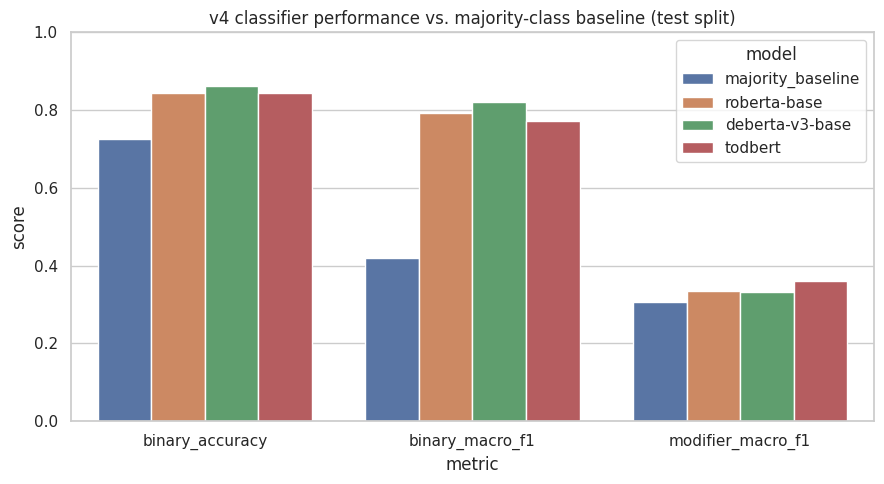

In [16]:
plot_df = summary_df.melt(
    id_vars="model",
    value_vars=["binary_accuracy", "binary_macro_f1", "modifier_macro_f1"],
    var_name="metric", value_name="score",
)
plt.figure(figsize=(9, 5))
sns.barplot(data=plot_df, x="metric", y="score", hue="model")
plt.ylim(0, 1)
plt.title("v4 classifier performance vs. majority-class baseline (test split)")
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["out_dir"], f"classifier_comparison_bar_{CONFIG['run_tag']}.png"), dpi=150)
plt.show()

### 10b. Confusion matrices — binary_label, per encoder

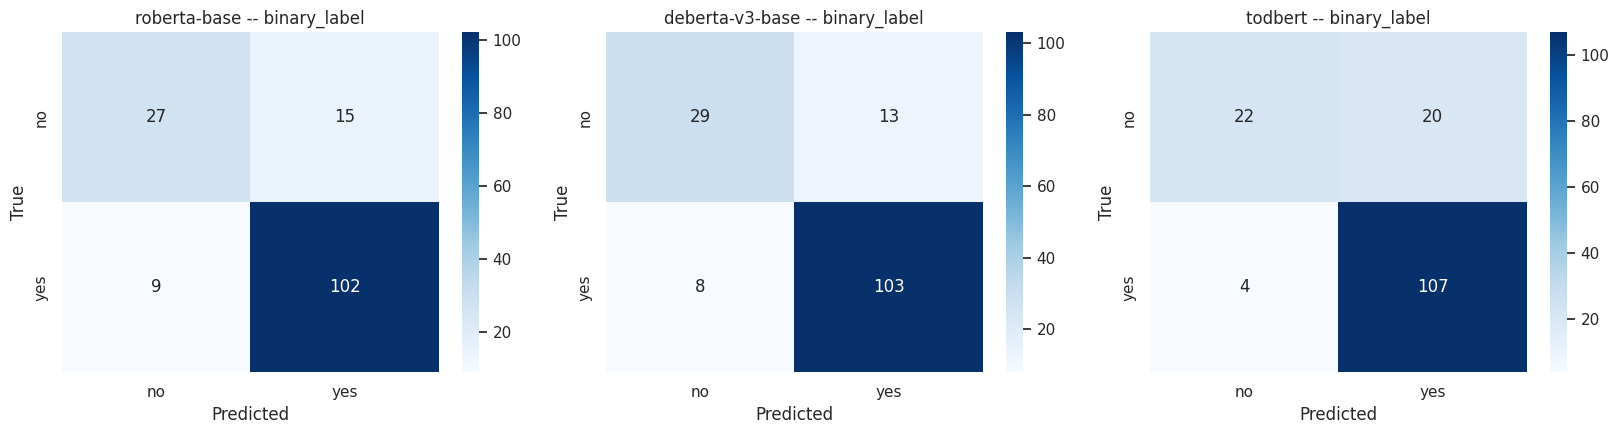

In [17]:
fig, axes = plt.subplots(1, len(results), figsize=(5.5 * len(results), 4.5))
if len(results) == 1:
    axes = [axes]
for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(r["test_metrics"]["binary_true"], r["test_metrics"]["binary_pred"],
                           labels=list(range(len(CONFIG["binary_classes"]))))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CONFIG["binary_classes"], yticklabels=CONFIG["binary_classes"], ax=ax)
    ax.set_title(f"{name} -- binary_label")
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["out_dir"], f"confusion_matrix_binary_{CONFIG['run_tag']}.png"), dpi=150)
plt.show()

### 10c. Confusion matrices — modifier, per encoder

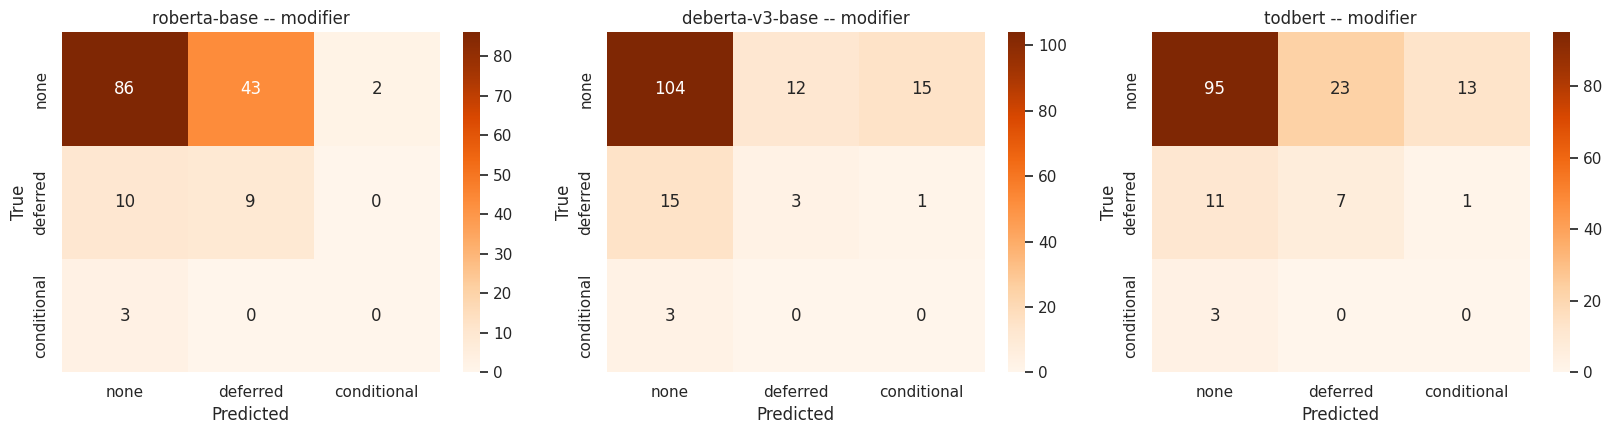

In [18]:
fig, axes = plt.subplots(1, len(results), figsize=(5.5 * len(results), 4.5))
if len(results) == 1:
    axes = [axes]
for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(r["test_metrics"]["modifier_true"], r["test_metrics"]["modifier_pred"],
                           labels=list(range(len(CONFIG["modifier_classes"]))))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges",
                xticklabels=CONFIG["modifier_classes"], yticklabels=CONFIG["modifier_classes"], ax=ax)
    ax.set_title(f"{name} -- modifier")
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["out_dir"], f"confusion_matrix_modifier_{CONFIG['run_tag']}.png"), dpi=150)
plt.show()

### 10d. Training curves — val F1 per epoch, per encoder

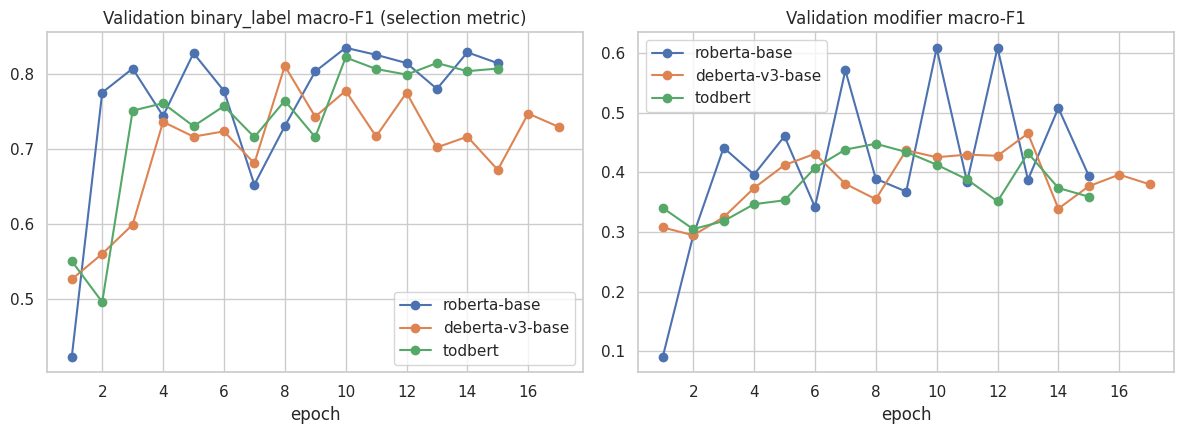

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for name, r in results.items():
    hist = pd.DataFrame(r["history"])
    axes[0].plot(hist["epoch"], hist["val_binary_macro_f1"], marker="o", label=name)
    axes[1].plot(hist["epoch"], hist["val_modifier_macro_f1"], marker="o", label=name)
axes[0].set_title("Validation binary_label macro-F1 (selection metric)"); axes[0].set_xlabel("epoch"); axes[0].legend()
axes[1].set_title("Validation modifier macro-F1"); axes[1].set_xlabel("epoch"); axes[1].legend()
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["out_dir"], f"training_curves_{CONFIG['run_tag']}.png"), dpi=150)
plt.show()

## 10e. Classification reports (full precision/recall/F1 per class)

In [20]:
for name, r in results.items():
    _sep = "=" * 70
    print(f"\n{_sep}\n{name} -- binary_label classification report\n{_sep}")
    print(classification_report(r["test_metrics"]["binary_true"], r["test_metrics"]["binary_pred"],
                                 target_names=CONFIG["binary_classes"], zero_division=0))
    print(f"{name} -- modifier classification report")
    print(classification_report(r["test_metrics"]["modifier_true"], r["test_metrics"]["modifier_pred"],
                                 target_names=CONFIG["modifier_classes"], zero_division=0))


roberta-base -- binary_label classification report
              precision    recall  f1-score   support

          no       0.75      0.64      0.69        42
         yes       0.87      0.92      0.89       111

    accuracy                           0.84       153
   macro avg       0.81      0.78      0.79       153
weighted avg       0.84      0.84      0.84       153

roberta-base -- modifier classification report
              precision    recall  f1-score   support

        none       0.87      0.66      0.75       131
    deferred       0.17      0.47      0.25        19
 conditional       0.00      0.00      0.00         3

    accuracy                           0.62       153
   macro avg       0.35      0.38      0.33       153
weighted avg       0.77      0.62      0.67       153


deberta-v3-base -- binary_label classification report
              precision    recall  f1-score   support

          no       0.78      0.69      0.73        42
         yes       0.89      

## 11. Summary

v8 = v6's hierarchical dialogue encoder (OOM-fixed) + v7's augmentation
pipeline (connective paraphrase + back-translation). Model, loss, and
training loop are v6's, unchanged beyond the OOM fixes; augmentation is
v7's, unchanged.

| Component | From | Status going in |
|---|---|---|
| Hierarchical encoder + dialogue Transformer | v6 | 1/3 encoders (RoBERTa) completed with strong results before an OOM on DeBERTa-v3; OOM fixed here (batch size, gradient checkpointing, allocator config) but not yet re-verified end-to-end |
| Connective paraphrase + back-translation augmentation | v7 | Ran successfully end-to-end; verified 0% marker corruption on both paths; did not clearly improve results on the flat (v5) architecture |

**What to look for in this run's results**: does pairing the two changes
compound (better than either alone), or does the hierarchical encoder's
own gain simply dominate regardless of augmentation source (i.e. v8 ≈
v6-fixed's numbers, augmentation quality turns out not to matter much
once truncation is fixed)? Either answer is useful — it settles whether
v7's augmentation upgrade was solving the wrong problem, or whether it
just needed the truncation fix to show its effect.

**Still true**: `conditional` has only 13 real source dialogues total, in
any architecture. If it's still at or near 0 F1 here, that continues to
point at labeled-data scarcity as the remaining ceiling, not the model or
the augmentation pipeline.